In [11]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from time import perf_counter
import time
from pathlib import Path
from matplotlib.ticker import FuncFormatter
import copy

np.set_printoptions(precision=5, suppress=True)

from portfolio_core import (
    MutualFundConfig,
    MutualFundModel,
    build_model_arrays,
    gauss_hermite_multinormal,
    debt_to_farm_asset_ratio,
    resulting_dfa_after_trade,
    mutual_vmaxh,
    solve_mutual_coefficients,
    mutual_transition_next_state
)


# Replication

#### Table 5

In [ ]:
# Replication of Lohano and King (2009)'s Table 8 for the model with mutual funds.

rng = np.random.default_rng(42)
n_sims = 500 #500
n_years = 10 #10

timings = {
    "solve_coefficients": 0.0,
    "build_arrays": 0.0,
    "quadrature_setup": 0.0,
    "optimize_controls": 0.0,
    "draw_shocks": 0.0,
    "state_transition_active": 0.0,
    "state_transition_out": 0.0,
    "summary_update": 0.0,
    "format_output": 0.0,
}
run_t0 = time.perf_counter()

model = MutualFundModel()
cfg = model.config
cfg.Ee = (0.0, 0.0, 0.0)
#cfg.theta=0.0

cfg.search_mode = "vectorized"  # 'matlab', 'vectorized', or 'two_stage'
cfg.cost_scale_eta = 1.0
cfg.value_backend = "numba"
cfg.cost_scale_eta = 1.0
cfg.cost_scale_ref = 600.0
cfg.CRRA = True   # Set to False to run CARA utility mode.
cfg.m = (3, 3, 3)
cfg.dau = 0.7 #Credit limit parameter from paper.
cfg.var_cov = (
    (0.030186, 0.0, 0.0),
    (0.0, 0.017292, 0.0),
    (0.0, 0.0, 0.026941),
)


_mutual_copt_cache = {}

t0 = time.perf_counter()

print(f"Solving coefficients with q={cfg.q}, q2={cfg.q2}...")
cache_key = (
    cfg.n, cfg.q, cfg.q2, cfg.m, cfg.T, cfg.t1, cfg.theta, cfg.b,
    cfg.dau, bool(cfg.CRRA), cfg.Ee, cfg.var_cov
)

if cache_key not in _mutual_copt_cache:
    _mutual_copt_cache[cache_key] = solve_mutual_coefficients(cfg)
copt = _mutual_copt_cache[cache_key]
print("Done solving.")
#copt = _mutual_copt_cache
timings["solve_coefficients"] += time.perf_counter() - t0

t0 = time.perf_counter()
arrays = build_model_arrays(cfg)
timings["build_arrays"] += time.perf_counter() - t0

t0 = time.perf_counter()
shock_nodes, shock_weights = gauss_hermite_multinormal(arrays["m"], arrays["Ee"], arrays["VarCov"])
mean_e = np.asarray(cfg.Ee, dtype=float)
cov_e = np.asarray(cfg.var_cov, dtype=float)
timings["quadrature_setup"] += time.perf_counter() - t0

# Initial state
initial_wealth = 1_000_000.0
states = np.zeros((n_sims, 4), dtype=float)
states[:, 0] = 365.0        # R_0
states[:, 1] = 1775.0       # P_0
states[:, 2] = 600.0        # L_0
states[:, 3] = initial_wealth

summary_rows = [
    {
        "Year": 0,
        "Expected net wealth ($)": states[:, 3].mean(),
        "St. dev. of net wealth ($)": np.nan,
        "Expected farmland (acres)": states[:, 2].mean(),
        "Prob. of exiting farming": 0.0,
    }
]

for year in range(1, n_years + 1):
    #print(f"Year {year}/{n_years} - Simulating transitions for {n_sims} farmers...")
    yr_idx = year - 1
    coeffs_t = copt[:, yr_idx]
    t_eval = yr_idx

    active_mask = (states[:, 2] >= (arrays["sminv"][2] - 1.0)) & (states[:, 3] > 0.0)
    active_idx = np.where(active_mask)[0]

    next_states = states.copy()

    if active_idx.size > 0:
        active_states = states[active_idx]

        t0 = time.perf_counter()
        x_opt, xm_opt, _ = mutual_vmaxh(
            active_states, coeffs_t, t_eval, cfg, arrays, shock_nodes, shock_weights
        )
        timings["optimize_controls"] += time.perf_counter() - t0

        t0 = time.perf_counter()
        shocks = rng.multivariate_normal(mean=mean_e, cov=cov_e, size=active_idx.size)
        timings["draw_shocks"] += time.perf_counter() - t0
        
        t0 = time.perf_counter()
        next_active = mutual_transition_next_state(
            active_states, x_opt, xm_opt, shocks, cfg, arrays["sminv"], arrays["smaxv"]
        )
        next_states[active_idx] = next_active
        timings["state_transition_active"] += time.perf_counter() - t0

    t0 = time.perf_counter()
    out_idx = np.where(~active_mask)[0]
    if out_idx.size > 0:
        next_states[out_idx, 2] = 0.0
        positive_wealth = next_states[out_idx, 3] >= 0.0
        next_states[out_idx[positive_wealth], 3] = cfg.EgRM * next_states[out_idx[positive_wealth], 3]
        next_states[out_idx[~positive_wealth], 3] = (1.0 + cfg.rn) * next_states[out_idx[~positive_wealth], 3]
    timings["state_transition_out"] += time.perf_counter() - t0

    t0 = time.perf_counter()
    states = next_states
    exited = (states[:, 2] < 1.0) | (states[:, 3] <= 0.0)

    summary_rows.append(
        {
            "Year": year,
            "Expected net wealth ($)": states[:, 3].mean(),
            "St. dev. of net wealth ($)": states[:, 3].std(ddof=1),
            "Expected farmland (acres)": states[:, 2].mean(),
            "Prob. of exiting farming": exited.mean(),
        }
    )
    timings["summary_update"] += time.perf_counter() - t0

mutual_estimates_df = pd.DataFrame(summary_rows)

t0 = time.perf_counter()
table_display = mutual_estimates_df.copy()
table_display["Expected net wealth ($)"] = table_display["Expected net wealth ($)"].map(lambda v: f"{v:,.0f}")
table_display["St. dev. of net wealth ($)"] = table_display["St. dev. of net wealth ($)"].map(
    lambda v: "-" if pd.isna(v) else f"{v:,.0f}"
)
table_display["Expected farmland (acres)"] = table_display["Expected farmland (acres)"].map(lambda v: f"{v:,.0f}")
table_display["Prob. of exiting farming"] = table_display["Prob. of exiting farming"].map(lambda v: f"{v:.3f}")
timings["format_output"] += time.perf_counter() - t0

total_runtime = time.perf_counter() - run_t0
timing_df = pd.DataFrame(
    [{"Step": k, "Seconds": v} for k, v in timings.items()]
).sort_values("Seconds", ascending=False)
timing_df["Share (%)"] = np.where(total_runtime > 0.0, 100.0 * timing_df["Seconds"] / total_runtime, 0.0)

print(f"Total Table 8 runtime: {total_runtime:.3f}s")
print("Step timing (sorted):")
for _, row in timing_df.iterrows():
    print(f"  {row['Step']:<24} {row['Seconds']:>8.3f}s   {row['Share (%)']:>6.2f}%")
if not timing_df.empty:
    slowest = timing_df.iloc[0]
    print(f"Longest step: {slowest['Step']} ({slowest['Seconds']:.3f}s)")

table8_step_timing = timing_df.reset_index(drop=True)

table_display

Solving coefficients with q=41, q2=25...
Done solving.
Total Table 8 runtime: 113.915s
Step timing (sorted):
  solve_coefficients        108.214s    95.00%
  optimize_controls           5.687s     4.99%
  format_output               0.002s     0.00%
  draw_shocks                 0.002s     0.00%
  state_transition_active     0.001s     0.00%
  quadrature_setup            0.001s     0.00%
  summary_update              0.000s     0.00%
  state_transition_out        0.000s     0.00%
  build_arrays                0.000s     0.00%
Longest step: solve_coefficients (108.214s)


,Year,Expected net wealth ($),St. dev. of net wealth ($),Expected farmland (acres),Prob. of exiting farming
0,0,"1,000,000",-,600,0.000
1,1,"1,069,813","168,529",600,0.000
2,2,"1,144,909","268,361",654,0.002
3,3,"1,241,602","353,393",743,0.004
4,4,"1,359,770","465,528",834,0.020
5,5,"1,492,199","589,715",894,0.052
6,6,"1,624,063","720,736",931,0.064
7,7,"1,777,388","841,106",946,0.090
8,8,"1,965,490","988,901",974,0.102
9,9,"2,152,876","1,142,193",955,0.116


In [13]:

metric_makecell = {
    "Expected net wealth ($)": r"\makecell{Expected net\\wealth (\$)}",
    "St. dev. of net wealth ($)": r"\makecell{St. dev. of\\net wealth (\$)}",
    "Expected farmland (acres)": r"\makecell{Expected farmland\\(acres)}",
    "Prob. of exiting farming": r"\makecell{Prob. of exiting\\farming}",
}
table8_makecell = table_display.rename(columns=metric_makecell)

latex_str = table8_makecell.to_latex(
    index=False,
    escape=False,  # keep \makecell commands
    column_format="cccccc",
    caption="Table 8-style policy table (model with mutual fund)",
    label="tab:table8_mutual_makecell",
)

tex_path = "Tables/table8_makecell.tex"
with open(tex_path, "w") as f:
    f.write(latex_str)

print(f"Saved LaTeX table to: {tex_path}")
print("Add \\usepackage{makecell} to your LaTeX preamble.")


Saved LaTeX table to: Tables/table8_makecell.tex
Add \usepackage{makecell} to your LaTeX preamble.


#### Table 4

In [14]:

copt_table7_mutual = _mutual_copt_cache[cache_key]
arrays_m = build_model_arrays(cfg)
shock_nodes_m, shock_weights_m = gauss_hermite_multinormal(arrays_m["m"], arrays_m["Ee"], arrays_m["VarCov"] )

Lt = 600.0
Rt = 365.0
prices = [1500.0, 1775.0]
wealth_levels = [400_000.0, 600_000.0, 1_000_000.0]
rows = []
for P in prices:
    for W in wealth_levels:
        state = np.array([[Rt, P, Lt, W]], dtype=float)
        x_opt, xm_opt, _ = mutual_vmaxh(
            state,
            copt_table7_mutual[:, 0],
            0,
            cfg, 
            arrays_m,
            shock_nodes_m,
            shock_weights_m,
        )
        x_star = float(x_opt[0])
        xm_star = float(xm_opt[0])
        rows.append(
            {
                "Current farmland price ($)": int(P),
                "Net wealth ($)": int(W),
                "Debt-to-farm-asset ratio": debt_to_farm_asset_ratio(P, Lt, W),
                "Optimal farmland transaction (acres)": x_star,
                "Optimal mutual-fund investment ($)": xm_star,
                "Resulting debt-to-farm-asset ratio": resulting_dfa_after_trade(P, Lt, W, x_star, xm_star),
            }
        )

table7_with_mutual = pd.DataFrame(rows)
display_table7_with_mutual = table7_with_mutual.copy()
display_table7_with_mutual["Net wealth ($)"] = display_table7_with_mutual["Net wealth ($)"].map(lambda v: f"{v:,.0f}")
display_table7_with_mutual["Debt-to-farm-asset ratio"] = display_table7_with_mutual["Debt-to-farm-asset ratio"].map(lambda v: f"{v:.2f}")
display_table7_with_mutual["Optimal farmland transaction (acres)"] = display_table7_with_mutual["Optimal farmland transaction (acres)"].map(lambda v: f"{v:,.0f}")
display_table7_with_mutual["Optimal mutual-fund investment ($)"] = display_table7_with_mutual["Optimal mutual-fund investment ($)"].map(lambda v: f"{v:,.0f}")
display_table7_with_mutual["Resulting debt-to-farm-asset ratio"] = display_table7_with_mutual["Resulting debt-to-farm-asset ratio"].map(lambda v: f"{v:.2f}")

print("Table 7-style policy table - Model with mutual fund (simulation-based policy evaluation, theta=1)")
display(display_table7_with_mutual)


Table 7-style policy table - Model with mutual fund (simulation-based policy evaluation, theta=1)


,Current farmland price ($),Net wealth ($),Debt-to-farm-asset ratio,Optimal farmland transaction (acres),Optimal mutual-fund investment ($),Resulting debt-to-farm-asset ratio
0,1500,"400,000",0.61,-200,"49,330",0.48
1,1500,"600,000",0.41,0,"209,652",0.61
2,1500,"1,000,000",0.01,0,"492,986",0.50
3,1775,"400,000",0.66,-600,"400,000",0.00
4,1775,"600,000",0.49,-200,"137,362",0.41
5,1775,"1,000,000",0.14,0,"568,269",0.63


In [15]:
metric_makecell= {
    "Current farmland price ($)": r"\makecell{Current farmland\\price (\$)}",
    "Net wealth ($)": r"\makecell{Net wealth\\(\$)}",
    "Debt-to-farm-asset ratio": r"\makecell{Debt-to-farm-asset\\ratio}",
    "Optimal farmland transaction (acres)": r"\makecell{Optimal farmland\\transaction (acres)}",
    "Optimal mutual-fund investment ($)": r"\makecell{Optimal mutual-fund\\investment (\$)}",
    "Resulting debt-to-farm-asset ratio": r"\makecell{Resulting debt-to-farm-asset\\ratio}",
}
table7_makecell = display_table7_with_mutual.rename(columns=metric_makecell)

latex_str = table7_makecell.to_latex(
    index=False,
    escape=False,  
    column_format="cccccc",
    caption="Table 7-style policy table (model with mutual fund)",
    label="tab:table7_mutual_makecell",
)

tex_path = "Tables/table7_makecell.tex"
with open(tex_path, "w") as f:
    f.write(latex_str)

print(f"Saved LaTeX table to: {tex_path}")
print("Add \\usepackage{makecell} to your LaTeX preamble.")

Saved LaTeX table to: Tables/table7_makecell.tex
Add \usepackage{makecell} to your LaTeX preamble.


#### Figure 2

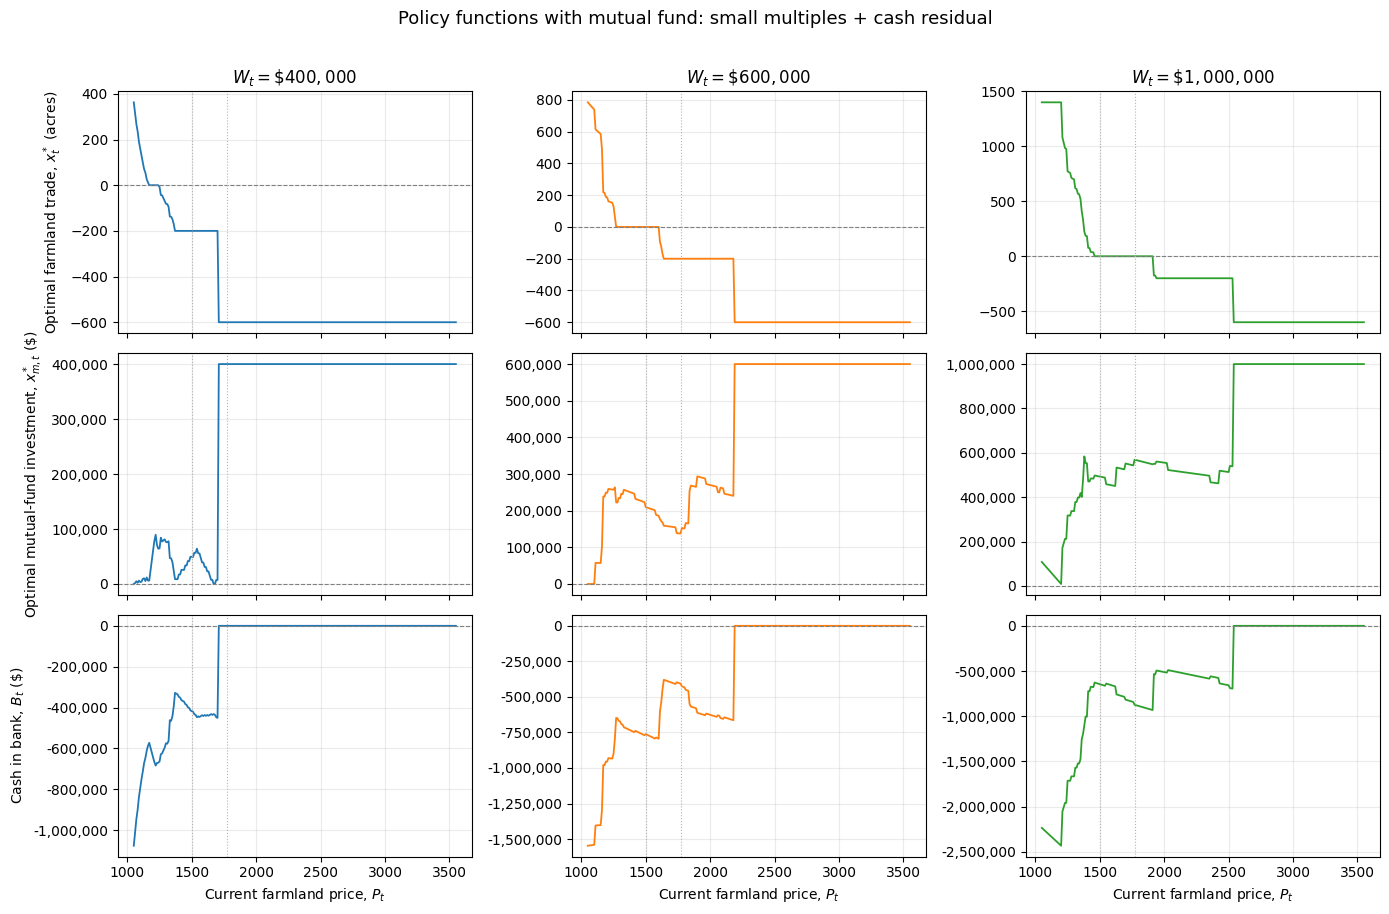

Saved figure to: Graphs/policy_small_multiples_mutual_with_bank.png


In [16]:

if "cfg" not in globals():
    raise RuntimeError("cfg not found. Run the model setup cells first.")

if "copt_table7_mutual" in globals():
    copt_plot = copt_table7_mutual
elif "cache_key" in globals() and "_mutual_copt_cache" in globals() and cache_key in _mutual_copt_cache:
    copt_plot = _mutual_copt_cache[cache_key]
else:
    raise RuntimeError("No cached mutual coefficients found. Run coefficient-solve cells first.")

arrays_plot = build_model_arrays(cfg)
shock_nodes_plot, shock_weights_plot = gauss_hermite_multinormal(
    arrays_plot["m"], arrays_plot["Ee"], arrays_plot["VarCov"]
)

Rt = 365.0
Lt = 600.0
wealth_levels = [400_000.0, 600_000.0, 1_000_000.0]
P_grid = np.linspace(1050.0, 3550.0, 251)

land_curves = {}
mutual_curves = {}
bank_curves = {}
for W in wealth_levels:
    states = np.column_stack([
        np.full_like(P_grid, Rt, dtype=float),
        P_grid,
        np.full_like(P_grid, Lt, dtype=float),
        np.full_like(P_grid, W, dtype=float),
    ])
    x_opt, xm_opt, _ = mutual_vmaxh(
        states,
        copt_plot[:, 0],
        0,
        cfg,
        arrays_plot,
        shock_nodes_plot,
        shock_weights_plot,
    )
    x_star = np.asarray(x_opt, dtype=float)
    xm_star = np.asarray(xm_opt, dtype=float)
    land_curves[W] = x_star
    mutual_curves[W] = xm_star

    # Implied bank/cash residual after land and mutual-fund choices.
    sell_price_now = (1.0 - cfg.tcs) * P_grid + (1.0 - cfg.fds) * cfg.fme
    buy_price = (1.0 + cfg.tcb) * P_grid + cfg.fme
    sell_mask = x_star < 0.0
    buy_price[sell_mask] = (1.0 - cfg.tcs) * P_grid[sell_mask] + (1.0 - cfg.fds) * cfg.fme
    equity_now = W - sell_price_now * Lt
    eta = float(getattr(cfg, "cost_scale_eta", 1.0))
    lref = max(float(getattr(cfg, "cost_scale_ref", 600.0)), 1e-12)
    L_post = np.maximum(Lt + x_star, 0.0)
    operating_cost = cfg.cost * (lref ** (1.0 - eta)) * (L_post ** eta)
    bank_curves[W] = equity_now - buy_price * x_star - operating_cost - xm_star

fig, axes = plt.subplots(3, len(wealth_levels), figsize=(14, 9), sharex=True)
colors = ["tab:blue", "tab:orange", "tab:green"]
money_fmt = FuncFormatter(lambda x, _: f"{x:,.0f}")

for j, (W, c) in enumerate(zip(wealth_levels, colors)):
    ax_top = axes[0, j]
    ax_mid = axes[1, j]
    ax_bot = axes[2, j]

    ax_top.plot(P_grid, land_curves[W], color=c, linewidth=1.3)
    ax_top.axhline(0.0, color="0.5", linestyle="--", linewidth=0.8)
    ax_top.axvline(1500.0, color="0.7", linestyle=":", linewidth=0.8)
    ax_top.axvline(1775.0, color="0.7", linestyle=":", linewidth=0.8)
    ax_top.grid(alpha=0.25)
    ax_top.set_title(rf"$W_t=\${int(W):,}$")

    ax_mid.plot(P_grid, mutual_curves[W], color=c, linewidth=1.3)
    ax_mid.axhline(0.0, color="0.5", linestyle="--", linewidth=0.8)
    ax_mid.axvline(1500.0, color="0.7", linestyle=":", linewidth=0.8)
    ax_mid.axvline(1775.0, color="0.7", linestyle=":", linewidth=0.8)
    ax_mid.ticklabel_format(style="plain", axis="y", useOffset=False)
    ax_mid.yaxis.set_major_formatter(money_fmt)
    ax_mid.grid(alpha=0.25)

    ax_bot.plot(P_grid, bank_curves[W], color=c, linewidth=1.3)
    ax_bot.axhline(0.0, color="0.5", linestyle="--", linewidth=0.8)
    ax_bot.axvline(1500.0, color="0.7", linestyle=":", linewidth=0.8)
    ax_bot.axvline(1775.0, color="0.7", linestyle=":", linewidth=0.8)
    ax_bot.ticklabel_format(style="plain", axis="y", useOffset=False)
    ax_bot.yaxis.set_major_formatter(money_fmt)
    ax_bot.grid(alpha=0.25)
    ax_bot.set_xlabel("Current farmland price, $P_t$")

axes[0, 0].set_ylabel("Optimal farmland trade, $x_t^*$ (acres)")
axes[1, 0].set_ylabel(r"Optimal mutual-fund investment, $x_{m,t}^*$ (\$)")
axes[2, 0].set_ylabel(r"Cash in bank, $B_t$ (\$)")

fig.suptitle("Policy functions with mutual fund: small multiples + cash residual", y=1.01, fontsize=13)
fig.tight_layout()

Path("Graphs").mkdir(parents=True, exist_ok=True)
out_path = "Graphs/policy_small_multiples_mutual_with_bank.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved figure to: {out_path}")


# $\rho$ comparison

Solving coefficients for rho/dau=0.40...
Solving coefficients for rho/dau=1.00...


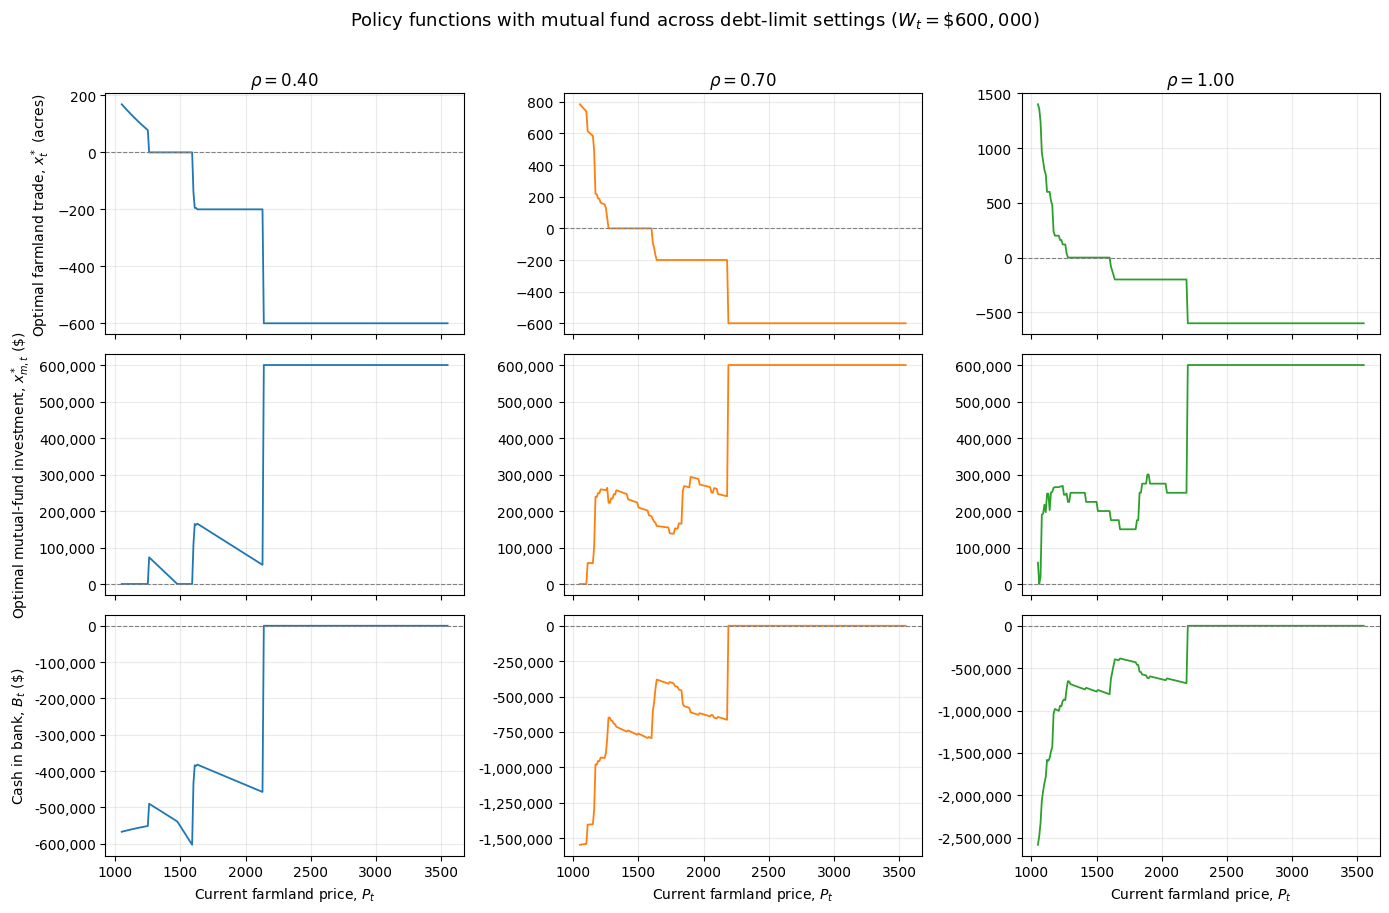

Saved figure to: Graphs/policy_small_multiples_rho_dau_with_bank.png


In [17]:

if "cfg" not in globals():
    raise RuntimeError("cfg not found. Run the model setup cells first.")

if "_mutual_copt_cache" not in globals():
    _mutual_copt_cache = {}

Rt = 365.0
Lt = 600.0
W_fixed = 600_000.0
dau_levels = [0.4, 0.7, 1.0]
P_grid = np.linspace(1050.0, 3550.0, 251)


def _cache_key_for_cfg(cfg_obj):
    return (
        cfg_obj.n,
        cfg_obj.q,
        cfg_obj.q2,
        cfg_obj.m,
        cfg_obj.T,
        cfg_obj.t1,
        cfg_obj.theta,
        cfg_obj.b,
        cfg_obj.dau,
        bool(cfg_obj.CRRA),
        cfg_obj.Ee,
        cfg_obj.var_cov,
    )


def _solve_for_dau(dau):
    if np.isclose(float(dau), float(cfg.dau)) and "copt_table7_mutual" in globals():
        cfg_plot = cfg
        copt_plot = copt_table7_mutual
    else:
        cfg_plot = MutualFundConfig()
        cfg_plot.dau = float(dau)
        cfg_plot.Ee = (0.0, 0.0, 0.0)
        cfg_plot.search_mode = "vectorized"
        cfg_plot.value_backend = "numba"
        cfg_plot.var_cov = (
            (0.030186, 0.0, 0.0),
            (0.0, 0.017292, 0.0),
            (0.0, 0.0, 0.026941),
        )

        key = _cache_key_for_cfg(cfg_plot)
        if key not in _mutual_copt_cache:
            print(f"Solving coefficients for rho/dau={dau:.2f}...")
            _mutual_copt_cache[key] = solve_mutual_coefficients(cfg_plot)
        copt_plot = _mutual_copt_cache[key]

    arrays_plot = build_model_arrays(cfg_plot)
    shock_nodes_plot, shock_weights_plot = gauss_hermite_multinormal(
        arrays_plot["m"], arrays_plot["Ee"], arrays_plot["VarCov"]
    )
    return cfg_plot, copt_plot, arrays_plot, shock_nodes_plot, shock_weights_plot


land_curves = {}
mutual_curves = {}
bank_curves = {}
for dau in dau_levels:
    cfg_plot, copt_plot, arrays_plot, shock_nodes_plot, shock_weights_plot = _solve_for_dau(dau)

    states = np.column_stack([
        np.full_like(P_grid, Rt, dtype=float),
        P_grid,
        np.full_like(P_grid, Lt, dtype=float),
        np.full_like(P_grid, W_fixed, dtype=float),
    ])
    x_opt, xm_opt, _ = mutual_vmaxh(
        states,
        copt_plot[:, 0],
        0,
        cfg_plot,
        arrays_plot,
        shock_nodes_plot,
        shock_weights_plot,
    )
    x_star = np.asarray(x_opt, dtype=float)
    xm_star = np.asarray(xm_opt, dtype=float)
    land_curves[dau] = x_star
    mutual_curves[dau] = xm_star

    # Implied bank/cash residual after land and mutual-fund choices.
    sell_price_now = (1.0 - cfg_plot.tcs) * P_grid + (1.0 - cfg_plot.fds) * cfg_plot.fme
    buy_price = (1.0 + cfg_plot.tcb) * P_grid + cfg_plot.fme
    sell_mask = x_star < 0.0
    buy_price[sell_mask] = (1.0 - cfg_plot.tcs) * P_grid[sell_mask] + (1.0 - cfg_plot.fds) * cfg_plot.fme
    equity_now = W_fixed - sell_price_now * Lt
    eta = float(getattr(cfg_plot, "cost_scale_eta", 1.0))
    lref = max(float(getattr(cfg_plot, "cost_scale_ref", 600.0)), 1e-12)
    L_post = np.maximum(Lt + x_star, 0.0)
    operating_cost = cfg_plot.cost * (lref ** (1.0 - eta)) * (L_post ** eta)
    bank_curves[dau] = equity_now - buy_price * x_star - operating_cost - xm_star

fig, axes = plt.subplots(3, len(dau_levels), figsize=(14, 9), sharex=True)
colors = ["tab:blue", "tab:orange", "tab:green"]
money_fmt = FuncFormatter(lambda x, _: f"{x:,.0f}")

for j, (dau, c) in enumerate(zip(dau_levels, colors)):
    ax_top = axes[0, j]
    ax_mid = axes[1, j]
    ax_bot = axes[2, j]

    ax_top.plot(P_grid, land_curves[dau], color=c, linewidth=1.3)
    ax_top.axhline(0.0, color="0.5", linestyle="--", linewidth=0.8)
    #ax_top.axvline(1500.0, color="0.7", linestyle=":", linewidth=0.8)
    #ax_top.axvline(1775.0, color="0.7", linestyle=":", linewidth=0.8)
    ax_top.grid(alpha=0.25)
    ax_top.set_title(rf"$\rho={dau:.2f}$")

    ax_mid.plot(P_grid, mutual_curves[dau], color=c, linewidth=1.3)
    ax_mid.axhline(0.0, color="0.5", linestyle="--", linewidth=0.8)
    #ax_mid.axvline(1500.0, color="0.7", linestyle=":", linewidth=0.8)
    #ax_mid.axvline(1775.0, color="0.7", linestyle=":", linewidth=0.8)
    ax_mid.ticklabel_format(style="plain", axis="y", useOffset=False)
    ax_mid.yaxis.set_major_formatter(money_fmt)
    ax_mid.grid(alpha=0.25)

    ax_bot.plot(P_grid, bank_curves[dau], color=c, linewidth=1.3)
    ax_bot.axhline(0.0, color="0.5", linestyle="--", linewidth=0.8)
    #ax_bot.axvline(1500.0, color="0.7", linestyle=":", linewidth=0.8)
    #ax_bot.axvline(1775.0, color="0.7", linestyle=":", linewidth=0.8)
    ax_bot.ticklabel_format(style="plain", axis="y", useOffset=False)
    ax_bot.yaxis.set_major_formatter(money_fmt)
    ax_bot.grid(alpha=0.25)
    ax_bot.set_xlabel("Current farmland price, $P_t$")

axes[0, 0].set_ylabel("Optimal farmland trade, $x_t^*$ (acres)")
axes[1, 0].set_ylabel(r"Optimal mutual-fund investment, $x_{m,t}^*$ (\$)")
axes[2, 0].set_ylabel(r"Cash in bank, $B_t$ (\$)")

fig.suptitle(
    rf"Policy functions with mutual fund across debt-limit settings ($W_t=\${int(W_fixed):,}$)",
    y=1.01,
    fontsize=13,
)
fig.tight_layout()

Path("Graphs").mkdir(parents=True, exist_ok=True)
out_path = "Graphs/policy_small_multiples_rho_dau_with_bank.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved figure to: {out_path}")



# Economies of scale

#### Table 8

In [18]:
def _table8_with_scale_eta(scale_eta, seed=42, n_sims=500, n_years=10):
    rng = np.random.default_rng(seed)

    cfg_ext = copy.deepcopy(cfg)   
    cfg_ext.cost_scale_eta = float(scale_eta)
    cfg_ext.cost_scale_ref = 600.0
    

    if "_mutual_copt_cache" not in globals() or not isinstance(_mutual_copt_cache, dict):
        globals()["_mutual_copt_cache"] = {}

    cache_key = (
        cfg_ext.n,
        cfg_ext.q,
        cfg_ext.q2,
        cfg_ext.qf,
        cfg_ext.m,
        cfg_ext.T,
        cfg_ext.t1,
        cfg_ext.theta,
        cfg_ext.b,
        cfg_ext.dau,
        bool(cfg_ext.CRRA),
        cfg_ext.Ee,
        cfg_ext.var_cov,
        cfg_ext.cost,
        cfg_ext.cost_scale_eta,
        cfg_ext.cost_scale_ref,
    )

    if cache_key not in _mutual_copt_cache:
        print(f"Solving coefficients for eta={scale_eta:.2f}...")
        _mutual_copt_cache[cache_key] = solve_mutual_coefficients(cfg_ext)
    copt_ext = _mutual_copt_cache[cache_key]

    arrays = build_model_arrays(cfg_ext)
    shock_nodes, shock_weights = gauss_hermite_multinormal(arrays["m"], arrays["Ee"], arrays["VarCov"])

    mean_e = np.asarray(cfg_ext.Ee, dtype=float)
    cov_e = np.asarray(cfg_ext.var_cov, dtype=float)

    states = np.zeros((n_sims, 4), dtype=float)
    states[:, 0] = 365.0
    states[:, 1] = 1775.0
    states[:, 2] = 600.0
    states[:, 3] = 600_000.0

    rows = [{
        "Year": 0,
        "Expected net wealth ($)": states[:, 3].mean(),
        "St. dev. of net wealth ($)": np.nan,
        "Expected farmland (acres)": states[:, 2].mean(),
        "Prob. of exiting farming": 0.0,
    }]

    for year in range(1, n_years + 1):
        yr_idx = year - 1
        coeffs_t = copt_ext[:, yr_idx]
        active_mask = (states[:, 2] >= (arrays["sminv"][2] - 1.0)) & (states[:, 3] > 0.0)
        active_idx = np.where(active_mask)[0]
        next_states = states.copy()

        if active_idx.size > 0:
            active_states = states[active_idx]
            x_opt, xm_opt, _ = mutual_vmaxh(active_states, coeffs_t, yr_idx, cfg_ext, arrays, shock_nodes, shock_weights)
            # Match previous Table 8 protocol: draw shocks fresh each year for active farmers.
            shocks = rng.multivariate_normal(mean=mean_e, cov=cov_e, size=active_idx.size)
            next_active = mutual_transition_next_state(active_states, x_opt, xm_opt, shocks, cfg_ext, arrays["sminv"], arrays["smaxv"])
            next_states[active_idx] = next_active

        out_idx = np.where(~active_mask)[0]
        if out_idx.size > 0:
            next_states[out_idx, 2] = 0.0
            positive_wealth = next_states[out_idx, 3] >= 0.0
            next_states[out_idx[positive_wealth], 3] = cfg_ext.EgRM * next_states[out_idx[positive_wealth], 3]
            next_states[out_idx[~positive_wealth], 3] = (1.0 + cfg_ext.rn) * next_states[out_idx[~positive_wealth], 3]

        states = next_states
        exited = (states[:, 2] < 1.0) | (states[:, 3] <= 0.0)
        rows.append({
            "Year": year,
            "Expected net wealth ($)": states[:, 3].mean(),
            "St. dev. of net wealth ($)": states[:, 3].std(ddof=1),
            "Expected farmland (acres)": states[:, 2].mean(),
            "Prob. of exiting farming": exited.mean(),
        })

    df = pd.DataFrame(rows)
    return {
        "eta": float(scale_eta),
        "Year 10 expected wealth ($)": df.loc[df["Year"] == n_years, "Expected net wealth ($)"].iloc[0],
        "Year 10 st. dev. net wealth ($)": df.loc[df["Year"] == n_years, "St. dev. of net wealth ($)"].iloc[0],
        "Year 10 expected farmland (acres)": df.loc[df["Year"] == n_years, "Expected farmland (acres)"].iloc[0],
        "Year 10 exit probability": df.loc[df["Year"] == n_years, "Prob. of exiting farming"].iloc[0],
        "Avg exit probability (Y1-Y10)": df.loc[df["Year"] >= 1, "Prob. of exiting farming"].mean(),
    }


eta_scenarios = [1.00, 0.90, 0.80]
results = [_table8_with_scale_eta(eta) for eta in eta_scenarios]
extension_results_df = pd.DataFrame(results)

for col in [
    "Year 10 expected wealth ($)",
    "Year 10 st. dev. net wealth ($)",
    "Year 10 expected farmland (acres)",
    "Year 10 exit probability",
    "Avg exit probability (Y1-Y10)",
]:
    if "wealth" in col or "farmland" in col:
        extension_results_df[col] = extension_results_df[col].map(lambda v: f"{v:,.0f}")
    else:
        extension_results_df[col] = extension_results_df[col].map(lambda v: f"{v:.3f}")

print("Economies-of-scale extension results (lower eta => stronger scale economies):")
print(
    "  'Year 10 st. dev. net wealth': cross-simulation s.d. of net wealth at the final simulated year "
    "(same n_sims / n_years as _table8_with_scale_eta).\n"
)
display(extension_results_df)


Solving coefficients for eta=1.00...
Solving coefficients for eta=0.90...
Solving coefficients for eta=0.80...
Economies-of-scale extension results (lower eta => stronger scale economies):
  'Year 10 st. dev. net wealth': cross-simulation s.d. of net wealth at the final simulated year (same n_sims / n_years as _table8_with_scale_eta).



,eta,Year 10 expected wealth ($),Year 10 st. dev. net wealth ($),Year 10 expected farmland (acres),Year 10 exit probability,Avg exit probability (Y1-Y10)
0,1.0,"1,440,380","743,817",597,0.400,0.240
1,0.9,"1,532,470","977,957",729,0.384,0.231
2,0.8,"1,607,443","1,126,953",855,0.326,0.194


#### Figure 5

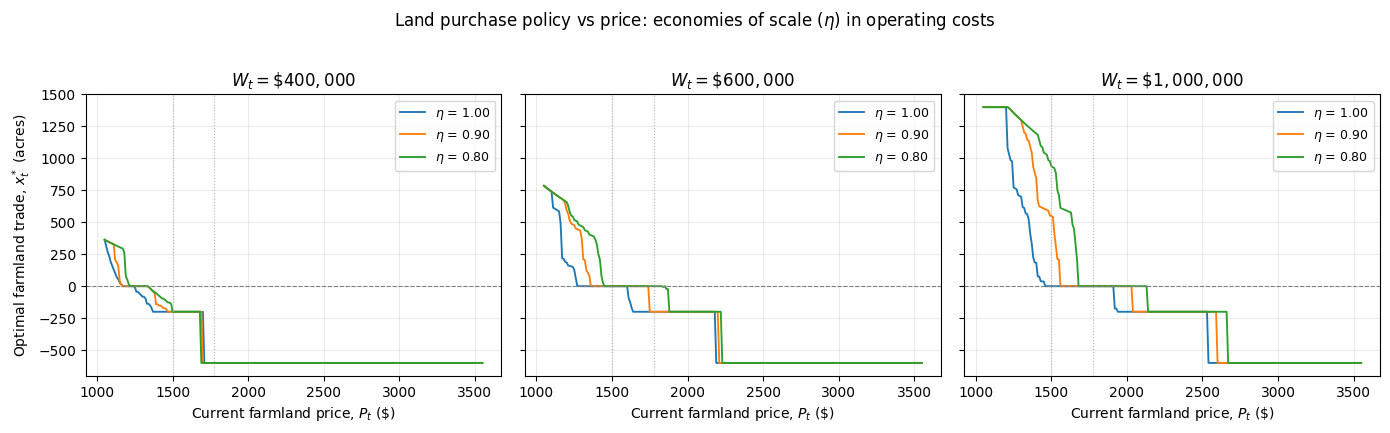

Saved figure to: Graphs/policy_land_trade_vs_price_by_eta.png


In [19]:
# Land purchase policy vs price for different cost-scale exponents eta (economies of scale)
from pathlib import Path
import copy

if "cfg" not in globals():
    raise RuntimeError("Run model setup cells first so `cfg` exists.")
if "_mutual_copt_cache" not in globals():
    raise RuntimeError("Run coefficient cells first so `_mutual_copt_cache` exists.")

eta_plot_list = list(eta_scenarios) if "eta_scenarios" in globals() else [1.0, 0.9, 0.8]

Rt_pol = 365.0
Lt_pol = 600.0
wealth_levels_pol = [400_000.0, 600_000.0, 1_000_000.0]
P_grid_pol = np.linspace(1050.0, 3550.0, 251)


def _resolve_eta_case(scale_eta):
    """Return (cfg_e, copt_e, arrays_e, shock_nodes_e, shock_weights_e) for a given cost_scale_eta."""
    cfg_e = copy.deepcopy(cfg)
    cfg_e.cost_scale_eta = float(scale_eta)
    cfg_e.cost_scale_ref = float(getattr(cfg, "cost_scale_ref", 600.0))
    cache_key_eta = (
        cfg_e.n,
        cfg_e.q,
        cfg_e.q2,
        cfg_e.qf,
        cfg_e.m,
        cfg_e.T,
        cfg_e.t1,
        cfg_e.theta,
        cfg_e.b,
        cfg_e.dau,
        bool(cfg_e.CRRA),
        cfg_e.Ee,
        cfg_e.var_cov,
        cfg_e.cost,
        cfg_e.cost_scale_eta,
        cfg_e.cost_scale_ref,
    )
    if cache_key_eta not in _mutual_copt_cache:
        print(f"  Solving coefficients for eta={float(scale_eta):.2f} (policy plot)...")
        _mutual_copt_cache[cache_key_eta] = solve_mutual_coefficients(cfg_e)
    copt_e = _mutual_copt_cache[cache_key_eta]
    arrays_e = build_model_arrays(cfg_e)
    shock_nodes_e, shock_weights_e = gauss_hermite_multinormal(
        arrays_e["m"], arrays_e["Ee"], arrays_e["VarCov"]
    )
    return cfg_e, copt_e, arrays_e, shock_nodes_e, shock_weights_e


fig, axes = plt.subplots(1, len(wealth_levels_pol), figsize=(14, 4.2), sharey=True)
axes = np.atleast_1d(axes)

for j, W in enumerate(wealth_levels_pol):
    ax = axes[j]
    for eta in eta_plot_list:
        cfg_e, copt_e, arrays_e, snd, swt = _resolve_eta_case(float(eta))
        states = np.column_stack(
            [
                np.full_like(P_grid_pol, Rt_pol, dtype=float),
                P_grid_pol,
                np.full_like(P_grid_pol, Lt_pol, dtype=float),
                np.full_like(P_grid_pol, W, dtype=float),
            ]
        )
        x_opt, _, _ = mutual_vmaxh(
            states,
            copt_e[:, 0],
            0,
            cfg_e,
            arrays_e,
            snd,
            swt,
        )
        ax.plot(
            P_grid_pol,
            np.asarray(x_opt, dtype=float),
            linewidth=1.35,
            label=rf"$\eta$ = {float(eta):.2f}",
        )
    ax.axhline(0.0, color="0.5", linestyle="--", linewidth=0.8)
    ax.axvline(1500.0, color="0.7", linestyle=":", linewidth=0.8)
    ax.axvline(1775.0, color="0.7", linestyle=":", linewidth=0.8)
    ax.grid(alpha=0.25)
    ax.set_title(rf"$W_t=\${int(W):,}$")
    ax.legend(loc="best", fontsize=9)

axes[0].set_ylabel(r"Optimal farmland trade, $x_t^*$ (acres)")
for ax in axes:
    ax.set_xlabel(r"Current farmland price, $P_t$ (\$)")

fig.suptitle(
    r"Land purchase policy vs price: economies of scale ($\eta$) in operating costs",
    y=1.02,
    fontsize=12,
)
fig.tight_layout()
Path("Graphs").mkdir(parents=True, exist_ok=True)
out_pol = "Graphs/policy_land_trade_vs_price_by_eta.png"
plt.savefig(out_pol, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved figure to: {out_pol}")


# No transaction costs

#### Figure 4

Solving model: tcs=0.06, tcb=0.01, rho=0.7
Solving model: tcs=0.0, tcb=0.0, rho=0.7


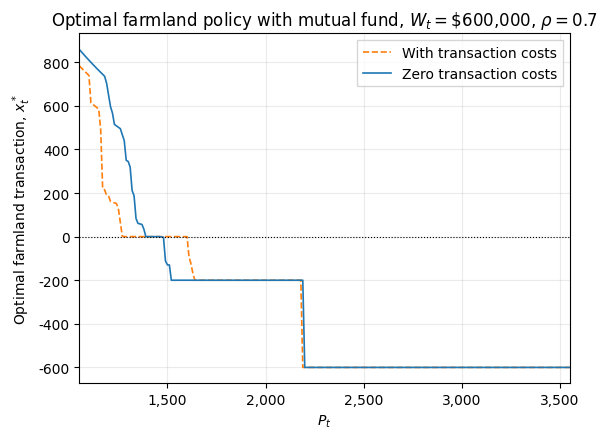

Saved figure to: Graphs/zero_transaction_costs_land_policy_mutual_W600k.png


In [20]:

# ---------- Formatter ----------
comma_formatter = FuncFormatter(lambda x, pos: f"{x:,.0f}")


# ---------- Helper function ----------
def solve_or_get_mutual(cfg_use, cache):
    key = (
        cfg_use.n,
        cfg_use.q,
        cfg_use.q2,
        cfg_use.m,
        cfg_use.T,
        cfg_use.t1,
        cfg_use.theta,
        cfg_use.b,
        cfg_use.dau,
        bool(cfg_use.CRRA),
        cfg_use.Ee,
        cfg_use.var_cov,
        cfg_use.tcs,
        cfg_use.tcb,
    )

    if key not in cache:
        print(
            f"Solving model: tcs={cfg_use.tcs}, tcb={cfg_use.tcb}, rho={cfg_use.dau}"
        )
        cache[key] = solve_mutual_coefficients(cfg_use)

    return cache[key]


def compute_land_policy_curve(cfg_use, copt_use, W, Rt=365.0, Lt=600.0):
    arrays_use = build_model_arrays(cfg_use)

    shock_nodes_use, shock_weights_use = gauss_hermite_multinormal(
        arrays_use["m"],
        arrays_use["Ee"],
        arrays_use["VarCov"]
    )

    P_grid = np.linspace(1050.0, 3550.0, 251)

    states = np.column_stack([
        np.full_like(P_grid, Rt, dtype=float),
        P_grid,
        np.full_like(P_grid, Lt, dtype=float),
        np.full_like(P_grid, W, dtype=float),
    ])

    x_opt, xm_opt, _ = mutual_vmaxh(
        states,
        copt_use[:, 0],
        0,
        cfg_use,
        arrays_use,
        shock_nodes_use,
        shock_weights_use,
    )

    return P_grid, np.asarray(x_opt, dtype=float)


# ---------- Baseline model ----------
cfg_baseline = copy.deepcopy(cfg)
cfg_baseline.dau = 0.7
cfg_baseline.tcs = 0.06
cfg_baseline.tcb = 0.01

copt_baseline = solve_or_get_mutual(cfg_baseline, _mutual_copt_cache)


# ---------- Zero transaction cost model ----------
cfg_zero_tc = copy.deepcopy(cfg)
cfg_zero_tc.dau = 0.7
cfg_zero_tc.tcs = 0.0
cfg_zero_tc.tcb = 0.0

copt_zero_tc = solve_or_get_mutual(cfg_zero_tc, _mutual_copt_cache)


# ---------- Compute policies for W_t = 600,000 ----------
W_fixed = 600_000.0

P_base, x_base = compute_land_policy_curve(
    cfg_baseline,
    copt_baseline,
    W_fixed
)

P_zero, x_zero = compute_land_policy_curve(
    cfg_zero_tc,
    copt_zero_tc,
    W_fixed
)


# ---------- Figure: Farmland transaction policy ----------
fig, ax = plt.subplots(figsize=(6.0, 4.5))

ax.plot(
    P_base,
    x_base,
    "--",
    linewidth=1.2,
    label=r"With transaction costs",
    color="tab:orange",
)

ax.plot(
    P_zero,
    x_zero,
    "-",
    linewidth=1.2,
    label=r"Zero transaction costs",
    color="tab:blue",
)

ax.axhline(0.0, color="black", linestyle=":", linewidth=0.8)

ax.set_title(r"Optimal farmland policy with mutual fund, $W_t=\$600{,}000$, $\rho=0.7$")
ax.set_xlabel(r"$P_t$")
ax.set_ylabel(r"Optimal farmland transaction, $x_t^*$")
ax.set_xlim(1050, 3550)

# Use full numbers with separators
ax.xaxis.set_major_formatter(comma_formatter)
ax.yaxis.set_major_formatter(comma_formatter)

ax.grid(alpha=0.25)
ax.legend(loc="upper right", frameon=True, fancybox=False)

plt.tight_layout()

Path("Graphs").mkdir(parents=True, exist_ok=True)
out_path_land = "Graphs/zero_transaction_costs_land_policy_mutual_W600k.png"
plt.savefig(out_path_land, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved figure to: {out_path_land}")